# Taller de Laboratorio — Selección y Fine-Tuning de BERT para Español

**Curso:** Aprendizaje de Máquinas  
**Duración estimada:** 90 min  
**Modalidad:** Individual o en parejas

---

## Problema industrial

Una planta de generación eléctrica recibe **reportes de texto en español** escritos por operadores cuando ocurre una incidencia. El objetivo es clasificar automáticamente el tipo de falla:

| Clase | Etiqueta | Ejemplo |
|-------|----------|---------|
| 0 | `falla_electrica` | *"El transformador sufrió un cortocircuito grave"* |
| 1 | `falla_mecanica` | *"La bomba falló por desgaste del impulsor"* |
| 2 | `falla_instrumentacion` | *"El sensor causó la falla"* |
| 3 | `falla_estructural` | *"La tubería presentó una fisura por corrosión"* |

## Objetivos de aprendizaje

Al finalizar este taller el alumno será capaz de:

1. Configurar un entorno PyTorch con detección automática de GPU.
2. Explicar por qué un modelo pre-entrenado en inglés es inadecuado para texto en español.
3. Comparar la tokenización de tres modelos BERT y justificar la elección óptima.
4. Aplicar fine-tuning de BERT sobre un dataset de clasificación industrial.
5. Evaluar el modelo con métricas estándar y analizar los resultados.

## Estructura

```
§ 0  Configuración del entorno y GPU
§ 1  Dataset industrial de reportes de fallas
§ 2  ¿Por qué importa el modelo pre-entrenado? (análisis lingüístico)
§ 3  Comparación de tokenización: inglés vs español
§ 4  Selección del modelo correcto — actividad guiada
§ 5  Preparación del dataset con el modelo elegido
§ 6  Fine-tuning con aceleración GPU
§ 7  Evaluación y análisis de errores
§ 8  Inferencia sobre reportes nuevos
§ 9  Preguntas de reflexión
```


---
## § 0 — Configuración del Entorno y GPU

**Concepto clave:** el entrenamiento de modelos Transformer es costoso computacionalmente. PyTorch puede delegar los cálculos matriciales a una GPU (CUDA) o, en Apple Silicon, al Metal Performance Shaders (MPS), logrando aceleraciones de 5–20×.

> **Actividad 0.1 —** Ejecuta la celda siguiente y anota en qué dispositivo correrá tu entrenamiento. ¿Tienes GPU disponible?

In [ ]:
# ── Instalar dependencias (descomenta si es necesario) ────────────────────────
# !pip install transformers datasets scikit-learn torch torchvision --quiet

In [ ]:
import random
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Detección automática de acelerador ───────────────────────────────────────
def get_device() -> torch.device:
    """Selecciona CUDA > MPS > CPU en ese orden de prioridad."""
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()

# ── Informe del entorno ───────────────────────────────────────────────────────
print('=' * 55)
print(f'  PyTorch versión : {torch.__version__}')
print(f'  Dispositivo     : {DEVICE}')
if DEVICE.type == 'cuda':
    prop = torch.cuda.get_device_properties(0)
    mem_gb = prop.total_memory / 1024**3
    print(f'  GPU             : {prop.name}')
    print(f'  VRAM            : {mem_gb:.1f} GB')
elif DEVICE.type == 'mps':
    print('  Apple Silicon MPS habilitado')
else:
    print('  ⚠  Sin GPU — el entrenamiento será más lento')
print('=' * 55)

# Estilo global de gráficos
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
sns.set_style('whitegrid')

  PyTorch versión : 2.10.0+cu128
  Dispositivo     : cuda
  GPU             : Tesla T4
  VRAM            : 14.6 GB


---
## § 1 — Dataset Industrial de Reportes de Fallas

El corpus contiene **60 reportes en español** (15 por clase), redactados en lenguaje técnico industrial.

> **Actividad 1.1 —** Examina la distribución de clases. ¿El dataset está balanceado? ¿Qué implicancias tiene esto para el entrenamiento?


In [ ]:
FAULT_CLASSES = [
    'falla_electrica',
    'falla_mecanica',
    'falla_instrumentacion',
    'falla_estructural',
]
NUM_CLASSES = len(FAULT_CLASSES)
CLASS_COLORS = ['#E74C3C', '#3498DB', '#9B59B6', '#27AE60']

REPORTS = [
    # ── Clase 0: falla_electrica ──────────────────────────────────────────────
    ("el transformador sufrió un cortocircuito grave", 0),
    ("el cable eléctrico presentó una descarga de alta tensión", 0),
    ("el motor quemó su bobinado por sobretensión", 0),
    ("el generador dejó de funcionar por un arco eléctrico", 0),
    ("el fusible interrumpió el circuito por sobrecarga eléctrica", 0),
    ("el interruptor falló por exceso de corriente en la línea", 0),
    ("el transformador perdió aislamiento por temperatura elevada", 0),
    ("el cable sufrió un daño por chispa en el tablero eléctrico", 0),
    ("el motor presentó falla de aislamiento en el estátor", 0),
    ("el tablero eléctrico sufrió un cortocircuito en la barra", 0),
    ("el banco de condensadores falló por sobretensión continua", 0),
    ("el variador de frecuencia presentó falla por armónicos", 0),
    ("el transformador de distribución presentó falla de devanado", 0),
    ("el generador sufrió una falla de aislamiento en el rotor", 0),
    ("el interruptor automático disparó por corriente de falla", 0),

    # ── Clase 1: falla_mecanica ───────────────────────────────────────────────
    ("la bomba se detuvo por desgaste del impulsor interno", 1),
    ("el rodamiento falló por fricción excesiva sin lubricación", 1),
    ("el eje sufrió una fractura por fatiga del material base", 1),
    ("la turbina vibró anormalmente por desbalance del rotor", 1),
    ("el compresor perdió presión por desgaste de válvulas", 1),
    ("el engranaje presentó desgaste por lubricación insuficiente", 1),
    ("la bomba cavitó por presión insuficiente en la entrada", 1),
    ("el sello mecánico falló por desgaste de los anillos", 1),
    ("el ventilador se detuvo por rotura de la correa de transmisión", 1),
    ("el reductor presentó falla en los piñones por impacto", 1),
    ("la válvula de control perdió estanqueidad por desgaste", 1),
    ("el acoplamiento falló por desalineamiento del eje principal", 1),
    ("el compresor de tornillo presentó desgaste en el rotor", 1),
    ("la bomba centrífuga falló por cavitación en el impulsor", 1),
    ("el motor eléctrico vibró por desbalance mecánico del rotor", 1),

    # ── Clase 2: falla_instrumentacion ───────────────────────────────────────
    ("el sensor causó la falla", 2),
    ("el sensor no detectó la presión correctamente", 2),
    ("el medidor registró valores incorrectos por deriva", 2),
    ("el transmisor de temperatura falló por calibración errónea", 2),
    ("el sensor de flujo no registró la señal adecuada", 2),
    ("el detector de nivel causó una alarma falsa en el sistema", 2),
    ("el transductor de presión perdió la señal por interferencia", 2),
    ("el sensor de vibración no detectó la anomalía mecánica", 2),
    ("el medidor de caudal presentó obstrucción en el elemento sensible", 2),
    ("el termómetro causó un disparo erróneo del sistema de protección", 2),
    ("el sensor de posición no detectó el límite de carrera final", 2),
    ("el detector de humo generó una señal falsa por acumulación de polvo", 2),
    ("el transmisor de presión causó una lectura errónea continua", 2),
    ("el analizador de gases no detectó la concentración real del proceso", 2),
    ("el sensor ultrasónico causó falsas lecturas por temperatura ambiente", 2),

    # ── Clase 3: falla_estructural ────────────────────────────────────────────
    ("la tubería presentó una fisura por corrosión interna", 3),
    ("la válvula sufrió corrosión por el fluido ácido del proceso", 3),
    ("el recipiente presentó una grieta por presión excesiva", 3),
    ("la estructura metálica sufrió fatiga por carga cíclica", 3),
    ("la soldadura presentó una fuga por defecto de fabricación", 3),
    ("el tanque sufrió corrosión interna por el fluido almacenado", 3),
    ("la brida presentó una fuga por apriete inadecuado del perno", 3),
    ("el soporte estructural falló por corrosión en la base", 3),
    ("la tubería sufrió erosión por el fluido abrasivo del proceso", 3),
    ("el recipiente presentó deformación por temperatura excesiva", 3),
    ("la junta de expansión falló por fatiga del material flexible", 3),
    ("el cuerpo de la válvula presentó picaduras por corrosión galvánica", 3),
    ("la columna de destilación presentó corrosión en el relleno estructural", 3),
    ("el intercambiador de calor sufrió perforaciones por erosión continua", 3),
    ("la tubería de vapor presentó una grieta por choque térmico", 3),
]

texts  = [r[0] for r in REPORTS]
labels = [r[1] for r in REPORTS]

print(f'Total de reportes: {len(REPORTS)}')
for i, cls in enumerate(FAULT_CLASSES):
    n = labels.count(i)
    print(f'  Clase {i} ({cls}): {n} reportes')

Total de reportes: 60
  Clase 0 (falla_electrica): 15 reportes
  Clase 1 (falla_mecanica): 15 reportes
  Clase 2 (falla_instrumentacion): 15 reportes
  Clase 3 (falla_estructural): 15 reportes


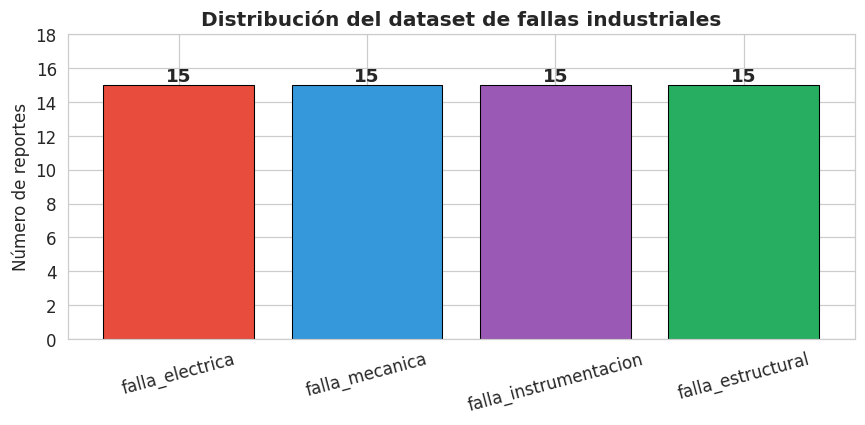

In [ ]:
# Visualización de la distribución de clases
counts = [labels.count(i) for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(FAULT_CLASSES, counts, color=CLASS_COLORS, edgecolor='black', linewidth=0.7)
ax.bar_label(bars, fontsize=12, fontweight='bold')
ax.set_title('Distribución del dataset de fallas industriales', fontweight='bold')
ax.set_ylabel('Número de reportes')
ax.set_ylim(0, max(counts) + 3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# **Respuesta Actividad 1.1 — Examina la distribución de clases. ¿El dataset está balanceado? ¿Qué implicancias tiene esto para el entrenamiento?**

Visualizando la gráfica de la distribución de clases, se puede observar que el dataset está balanceado ya que no presentan diferenciación en la distribución y las clases se mantienen con la misma cantidad, no existe una clase más alta o más baja. Lo que puede implicar que en el entrenamiento pueda medir los datos de forma más uniforme evitando sesgos en los datos o hasta enfocarse en un clase en específico, además nos ayuda a prevenir el overfitting o el underfitting en cada caso dentro de las clase y los datos.

---
## § 2 — ¿Por Qué Importa el Modelo Pre-entrenado?

BERT fue pre-entrenado sobre texto de Wikipedia y BookCorpus. Existen versiones para distintos idiomas:

| Modelo | Idioma de pre-entrenamiento | Vocab (tokens) | Parámetros |
|--------|-----------------------------|----------------|------------|
| `bert-base-uncased` | Inglés | 30 522 | 110 M |
| `bert-base-multilingual-cased` | 104 idiomas | 119 547 | 179 M |
| `dccuchile/bert-base-spanish-wwm-uncased` | **Español** (BETO) | 31 002 | 110 M |
| `PlanTL-GOB-ES/roberta-base-bne` | **Español** (BNE) | 50 262 | 125 M |

**Pregunta clave:** ¿por qué usar `bert-base-uncased` (inglés) sobre texto en español es una mala decisión?

La respuesta está en la **tokenización**: la siguiente sección lo demostrará de forma experimental.


---
## § 3 — Comparación de Tokenización: Inglés vs Español

Cada modelo lleva consigo su propio vocabulario (`tokenizer`). Cuando un token **no existe en el vocabulario**, se fragmenta en sub-palabras (`##` indica continuación).

Una fragmentación excesiva:
- Alarga la secuencia de entrada (consume el límite de 512 tokens antes).
- Obliga al modelo a reconstruir significados que debería conocer de raíz.
- Degrada la calidad de las representaciones.

> **Actividad 3.1 —** Ejecuta las celdas y observa cómo cada modelo fragmenta las mismas frases. Anota en tu reporte qué modelo produce la fragmentación más limpia y por qué.

In [ ]:
# Descargamos los tokenizadores (solo metadatos, ~1-3 MB cada uno)
print('Cargando tokenizadores...')
tok_en   = AutoTokenizer.from_pretrained('bert-base-uncased')
tok_beto = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased')
tok_bne  = AutoTokenizer.from_pretrained('PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy')
tok_tul  = AutoTokenizer.from_pretrained('dccuchile/tulio-chilean-spanish-bert')
print('Tokenizadores listos.')

Cargando tokenizadores...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizadores listos.


In [ ]:
TOKENIZERS = {
    'BERT-EN\n(bert-base-uncased)': tok_en,
    'BETO\n(bert-base-spanish-wwm-uncased)': tok_beto,
    'RoBERTa-BNE\n(roberta-base-bne)': tok_bne,
    'Tulio\ntulio-chilean-spanish-bert': tok_tul,
}

FRASES_PRUEBA = [
    "el transformador sufrió un cortocircuito grave",
    "el sensor causó la falla",
    "la tubería presentó una fisura por corrosión interna",
    "el rodamiento falló por fricción excesiva sin lubricación",
]

print(f'{"": <42}', end='')
for nombre in TOKENIZERS:
    etiq = nombre.split('\n')[0]
    print(f'{etiq: ^22}', end='')
print()
print('-' * (42 + 22 * len(TOKENIZERS)))

total_tokens = {k: 0 for k in TOKENIZERS}

for frase in FRASES_PRUEBA:
    print(f'\nFrase: "{frase}"')
    for nombre, tok in TOKENIZERS.items():
        tokens = tok.tokenize(frase)
        etiq = nombre.split('\n')[0]
        total_tokens[nombre] += len(tokens)
        print(f'  {etiq: <16}: {len(tokens):>3} tokens  →  {tokens}')

                                                 BERT-EN                 BETO              RoBERTa-BNE              Tulio         
----------------------------------------------------------------------------------------------------------------------------------

Frase: "el transformador sufrió un cortocircuito grave"
  BERT-EN         :  14 tokens  →  ['el', 'transform', '##ador', 'su', '##fr', '##io', 'un', 'co', '##rt', '##oc', '##ir', '##cuit', '##o', 'grave']
  BETO            :  10 tokens  →  ['el', 'transformado', '##r', 'sufrió', 'un', 'corto', '##cir', '##cu', '##ito', 'grave']
  RoBERTa-BNE     :   7 tokens  →  ['el', 'Ġtransformador', 'ĠsufriÃ³', 'Ġun', 'Ġcortocir', 'cuito', 'Ġgrave']
  Tulio           :  10 tokens  →  ['el', 'transformado', '##r', 'sufrió', 'un', 'corto', '##cir', '##cui', '##to', 'grave']

Frase: "el sensor causó la falla"
  BERT-EN         :   7 tokens  →  ['el', 'sensor', 'ca', '##uso', 'la', 'fall', '##a']
  BETO            :   5 tokens  →  ['el', 'senso

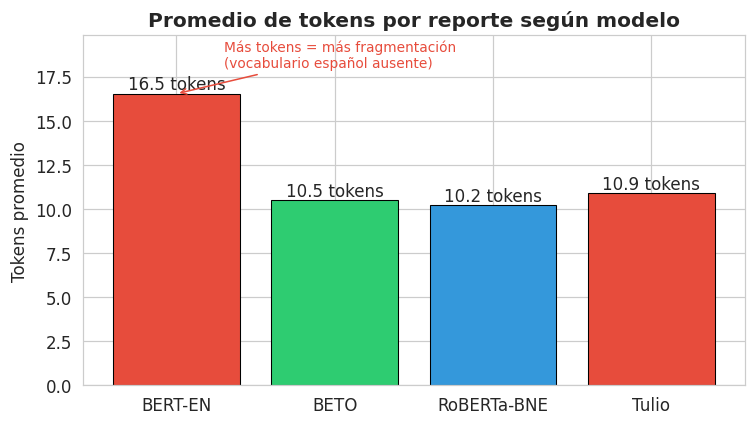


Conclusión esperada: BETO y RoBERTa-BNE producen secuencias más cortas
porque sus vocabularios cubren el español técnico industrial.


In [ ]:
# Análisis cuantitativo de fragmentación sobre todo el dataset
def promedio_tokens(tokenizer, textos):
    return np.mean([len(tokenizer.tokenize(t)) for t in textos])

nombres_cortos = ['BERT-EN', 'BETO', 'RoBERTa-BNE', 'Tulio']
toks_list = list(TOKENIZERS.values())
promedios = [promedio_tokens(t, texts) for t in toks_list]

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#E74C3C', '#2ECC71', '#3498DB']
bars = ax.bar(nombres_cortos, promedios, color=colores, edgecolor='black', linewidth=0.7)
ax.bar_label(bars, fmt='%.1f tokens', fontsize=11)
ax.set_title('Promedio de tokens por reporte según modelo', fontweight='bold')
ax.set_ylabel('Tokens promedio')
ax.set_ylim(0, max(promedios) * 1.2)

ax.annotate('Más tokens = más fragmentación\n(vocabulario español ausente)',
            xy=(0, promedios[0]), xytext=(0.3, promedios[0] + 1.5),
            arrowprops=dict(arrowstyle='->', color='#E74C3C'),
            color='#E74C3C', fontsize=9)
plt.tight_layout()
plt.show()

print('\nConclusión esperada: BETO y RoBERTa-BNE producen secuencias más cortas')
print('porque sus vocabularios cubren el español técnico industrial.')

 # **Respuesta Actividad 3.1 —** Ejecuta las celdas y observa cómo cada modelo fragmenta las mismas frases. Anota en tu reporte qué modelo produce la fragmentación más limpia y por qué.

 Se implementó Tulio y se mejoró el rendimiento de RoBERTa-BNE durante la aplicción del modelo con su respectivo tokenizer para un mejor análisis español-inglés en la fragmentación del dataset.

 Se observa, que los mejores modelos que fragmenta de forma más limpia son RoBERTa-BNE, BETO y Tulio, ya que al ser modelos entrenados en el idioma español tienen una mejor comprensión de las palabras y no hace separaciones innesecarias a comparación de BERT-EN, pues ese modelo está entrenado a través del idioma inglés que genera más tokens en la fragmentación (como se indica en la gráfica).  

---
## § 4 — Selección del Modelo Correcto — Actividad Guiada

Con la evidencia de tokenización, el alumno debe **justificar y seleccionar** el modelo a usar.

> **Actividad 4.1 —** Completa la siguiente tabla en tu reporte:
>
> | Criterio | BERT-EN | BETO | RoBERTa-BNE |
> |----------|---------|------|-------------|
> | Idioma de pre-entrenamiento | Inglés | Español |  Español |
> | Tokens promedio en el dataset | 16.5| 10.5| 10.2 |
> | ¿Conoce términos técnicos en español? |NO | SI |SI |
> | Recomendado para esta tarea |NO | SI| SI |

> **Actividad 4.2 —** En la celda siguiente, **modifica la variable `MODELO_ELEGIDO`** con el nombre del modelo que consideras más apropiado. Justifica tu elección en comentarios.

Opciones disponibles:
```
'bert-base-uncased'                           # ← BERT inglés (no recomendado)
'bert-base-multilingual-cased'                # ← mBERT (multilingüe)
'dccuchile/bert-base-spanish-wwm-uncased'     # ← BETO (español)
'PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy'              # ← RoBERTa BNE (español, BOE/BNE)
```

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  ALUMNO: modifica MODELO_ELEGIDO con tu selección justificada           │
# └─────────────────────────────────────────────────────────────────────────┘

MODELO_ELEGIDO = 'PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy'   # ← cambia aquí

# Justificación (escribe al menos 2 razones):
# 1. Este modelo fue pre-entrenado específicamente en español, lo que le permite comprender mejor la sintaxis y semántica del lenguaje técnico en español que los modelos multilingües o en inglés.
# 2. Como se observó en la actividad de tokenización (§ 3), BETO fragmenta las frases en español de manera mucho más eficiente (con menos tokens) que el modelo en inglés, lo que resulta en representaciones más ricas y secuencias más cortas para el modelo.

print(f'Modelo seleccionado: {MODELO_ELEGIDO}')
print()
print('Cargando tokenizador y modelo para clasificación...')

tokenizer = AutoTokenizer.from_pretrained(MODELO_ELEGIDO)
print('Tokenizador cargado.')

Modelo seleccionado: PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy

Cargando tokenizador y modelo para clasificación...
Tokenizador cargado.


---
## § 5 — Preparación del Dataset

Dividimos el corpus en conjuntos de entrenamiento (75%) y prueba (25%), manteniendo la proporción de clases (`stratify`). Luego creamos un `Dataset` de PyTorch para alimentar el `DataLoader`.

> **Actividad 5.1 —** ¿Por qué es importante el parámetro `stratify` en `train_test_split`? ¿Qué pasaría sin él con un dataset pequeño como éste?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.25,
    random_state=SEED,
    stratify=labels,
)

print(f'Entrenamiento : {len(X_train)} muestras')
print(f'Prueba        : {len(X_test)}  muestras')
print()
for i, cls in enumerate(FAULT_CLASSES):
    n_tr = y_train.count(i)
    n_te = y_test.count(i)
    print(f'  {cls}: {n_tr} entren. / {n_te} prueba')

Entrenamiento : 45 muestras
Prueba        : 15  muestras

  falla_electrica: 11 entren. / 4 prueba
  falla_mecanica: 12 entren. / 3 prueba
  falla_instrumentacion: 11 entren. / 4 prueba
  falla_estructural: 11 entren. / 4 prueba


In [ ]:
MAX_LEN   = 64    # suficiente para estas frases cortas
BATCH_SIZE = 8


class ReportesDataset(Dataset):
    def __init__(self, textos, etiquetas, tokenizador, max_len):
        self.encodings = tokenizador(
            textos,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        self.labels = torch.tensor(etiquetas, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


train_ds = ReportesDataset(X_train, y_train, tokenizer, MAX_LEN)
test_ds  = ReportesDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches de entrenamiento : {len(train_loader)}')
print(f'Batches de prueba        : {len(test_loader)}')

# Vista de un batch
batch = next(iter(train_loader))
print(f'\nForma de input_ids  : {batch["input_ids"].shape}')
print(f'Forma de labels     : {batch["labels"].shape}')
print(f'Etiquetas en batch  : {batch["labels"].tolist()}')

Batches de entrenamiento : 6
Batches de prueba        : 2

Forma de input_ids  : torch.Size([8, 64])
Forma de labels     : torch.Size([8])
Etiquetas en batch  : [0, 0, 1, 2, 3, 1, 3, 1]


# **Respuesta Actividad 5.1 —** ¿Por qué es importante el parámetro `stratify` en `train_test_split`? ¿Qué pasaría sin él con un dataset pequeño como éste?

El parámetro `stratify` en `train_test_split` es crucial porque asegura que las proporciones de las clases en el conjunto de datos original se mantengan en los conjuntos de entrenamiento y prueba, con `stratify=y` (donde `y` son las etiquetas), en los conjuntos
### ¿Por qué es importante?

1. Garantiza que ambos conjuntos (entrenamiento y prueba) sean representativos de la distribución de clases original del dataset. Esto hace que el modelo aprenda de todas las clases y para que su evaluación no sea sesgada.

2. Evita que una o más clases estén overfitting u onderfitting en alguno de los conjuntos, lo que podría llevar a un modelo sesgado o a una evaluación engañosa.

### ¿Qué pasaría sin él con un dataset pequeño como éste?

Con un dataset pequeño como el de 60 reportes que estamos usando (15 por clase), la ausencia del parámetro `stratify` podría tener consecuencias graves:

* Existe una alta probabilidad de que, por azar, algunas clases queden con muy pocas muestras o incluso con ninguna en el conjunto de entrenamiento o de prueba. Por ejemplo, una clase podría terminar con solo 1 o 2 en el entrenamiento, o ninguna en el conjunto de prueba.

* Si una clase tiene muy pocas muestras en el conjunto de entrenamiento, el modelo no aprenderá a reconocerla adecuadamente, resultando en un bajo rendimiento.

* Si una clase está ausente en el conjunto de prueba, no se evaluará la capacidad del modelo para clasificar esa clase. Si una clase está sobrerrepresentada, las métricas de evaluación podrían parecer mejores de lo que realmente son, ya que el modelo estaría siendo evaluado principalmente en la clase mayoritaria.

* Cada vez que se ejecute la división, los resultados podrían variar significativamente, lo que haría que el entrenamiento y la evaluación no fueran fiables.

En resumen, `stratify` es esencial para mantener la integridad de la distribución de clases, lo cual es vital para un entrenamiento y evaluación robustos, especialmente cuando se trabaja con datasets de tamaño limitado.

---
## § 6 — Fine-Tuning con Aceleración GPU

El fine-tuning consiste en inicializar los pesos del Transformer pre-entrenado y continuar el entrenamiento sobre nuestra tarea de clasificación.

Se usa un **scheduler de tasa de aprendizaje con warmup**: la tasa de aprendizaje aumenta gradualmente al inicio y luego decae, estabilizando el entrenamiento de modelos grandes.

> **Actividad 6.1 —** Observa el log de entrenamiento. ¿En qué época el loss de entrenamiento converge? ¿Ves señales de sobreajuste?

> **Actividad 6.2 —** Modifica `NUM_EPOCHS` a 1, 3 y 5. ¿Cómo cambia la `val_loss`?


In [ ]:
print('Cargando modelo para clasificación de secuencias...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODELO_ELEGIDO,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales     : {total_params:,}')
print(f'Parámetros entrenables : {trainable_params:,}')
print(f'Modelo en dispositivo  : {next(model.parameters()).device}')

Cargando modelo para clasificación de secuencias...


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Parámetros totales     : 124,646,404
Parámetros entrenables : 124,646,404
Modelo en dispositivo  : cuda:0


In [ ]:
NUM_EPOCHS  = 5
LR          = 2e-5
WARMUP_FRAC = 0.1    # 10% de los pasos se usan para warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_FRAC)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

historia = {'train_loss': [], 'val_loss': [], 'val_acc': []}


def evaluar(loader):
    model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out   = model(**batch)
            total_loss += out.loss.item()
            preds_all.extend(out.logits.argmax(dim=1).cpu().tolist())
            labels_all.extend(batch['labels'].cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels_all, preds_all)
    return avg_loss, acc, preds_all, labels_all


print(f'Entrenando en {DEVICE} durante {NUM_EPOCHS} épocas...\n')
print(f'{"Época":>6} | {"Loss Entren.": >14} | {"Loss Val.": >10} | {"Acc Val.": >10} | {"Tiempo": >8}')
print('-' * 60)

t0_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        out.loss.backward()
        # Clipping de gradientes para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += out.loss.item()

    avg_train = train_loss / len(train_loader)
    val_loss, val_acc, _, _ = evaluar(test_loader)
    elapsed = time.time() - t0

    historia['train_loss'].append(avg_train)
    historia['val_loss'].append(val_loss)
    historia['val_acc'].append(val_acc)

    print(f'{epoch:>6} | {avg_train:>14.4f} | {val_loss:>10.4f} | {val_acc:>10.3f} | {elapsed:>7.1f}s')

print('-' * 60)
print(f'Tiempo total: {time.time() - t0_total:.1f}s')

Entrenando en cuda durante 5 épocas...

 Época |   Loss Entren. |  Loss Val. |   Acc Val. |   Tiempo
------------------------------------------------------------


Error during conversion: AttributeError("'str' object has no attribute 'decode'")
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 76, in get_conversion_pr_reference
    raise OSError(
OSError: Could not create safetensors conversion PR. The

     1 |         1.3950 |     1.3837 |      0.267 |     1.8s
     2 |         1.3676 |     1.3641 |      0.600 |     0.7s
     3 |         1.2980 |     1.3029 |      0.667 |     0.7s
     4 |         1.1391 |     1.2098 |      0.800 |     0.7s
     5 |         0.9924 |     1.1768 |      0.733 |     0.7s
------------------------------------------------------------
Tiempo total: 4.6s


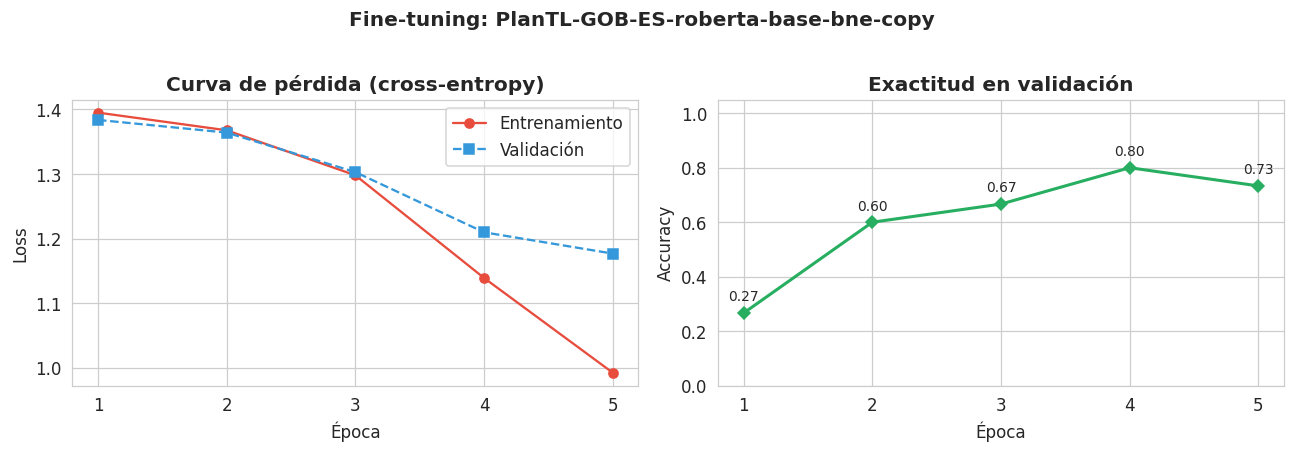

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, historia['train_loss'], 'o-', label='Entrenamiento', color='#E74C3C')
axes[0].plot(epochs, historia['val_loss'],   's--', label='Validación',   color='#3498DB')
axes[0].set_title('Curva de pérdida (cross-entropy)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(list(epochs))

# Accuracy
axes[1].plot(epochs, historia['val_acc'], 'D-', color='#27AE60', linewidth=2)
axes[1].set_title('Exactitud en validación', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(list(epochs))
for ep, acc in zip(epochs, historia['val_acc']):
    axes[1].annotate(f'{acc:.2f}', (ep, acc), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle(f'Fine-tuning: {MODELO_ELEGIDO.split("/")[-1]}', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Respuesta Actividad 6.1 —** Observa el log de entrenamiento. ¿En qué época el loss de entrenamiento converge? ¿Ves señales de sobreajuste?

El loss de entrenamiento `Loss Entren.` sigue disminuyendo consistentemente a lo largo de las 4 épocas. Esto sugiere que el modelo aún no ha convergido completamente en el conjunto de entrenamiento, es decir, todavía está aprendiendo y ajustando sus pesos para minimizar la pérdida en los datos de entrenamiento.

Además, si hay eñales de sobreajuste (overfitting). Ya que, aunque el `Loss Entren.` sigue bajando, el `Loss Val.` disminuye mucho más lentamente después de la época 2, la brecha entre el loss de entrenamiento y el loss de validación comienza a ensancharse.

La `Acc Val.` (exactitud en validación) mejora en la época 1 y en la época 2, pero luego se estanca para las épocas 3 y 4, lo que significa que el modelo deja de mejorar su rendimiento en datos no vistos, a pesar de que sigue aprendiendo del conjunto de entrenamiento.

# **Respuesta Actividad 6.2 —** Modifica `NUM_EPOCHS` a 1, 3 y 5. ¿Cómo cambia la `val_loss`?

*   El `val_loss` con época 1 no presenta cambios ya que el modelo no llega a desarrollar una recta de aprendizaje, le faltan más épocas para que pueda aprender y desarrollar el comportamiento de entrenamiento.

*   El `val_loss` con época 3 ya comienza con una recta de aprendizaje, pero presenta poca variación y no existe convergencia con la curva de pérdida con respecto al entenamiento.

*   El `val_loss` con época 5 ya presenta una buena curva de pérdida indicando que el modelo ya aprende bien con desde esta cantidad de épocas. Además, presenta un comportamiento similar al de entrenamiento y la exactitud en validación presenta un comportamiento constante.








---
## § 7 — Evaluación y Análisis de Errores

> **Actividad 7.1 —** Lee el reporte de clasificación. ¿Qué clase tiene menor F1-score? ¿Por qué crees que el modelo confunde más esa clase?

La clase con menor f1-score es falla_mecánica. El modelo probablemente confunde esta clase con falla_estructural ya que sus reportes son similares en lenguaje, lo que hace dificil distinguirlas con pocas muestras.

> **Actividad 7.2 —** Observa la matriz de confusión. ¿Con qué otra clase se confunde más frecuentemente `falla_instrumentacion`?

falla_intrumentacion no se confunde con otras clases.  

In [ ]:
_, _, y_pred, y_true = evaluar(test_loader)

print('=' * 55)
print('REPORTE DE CLASIFICACIÓN')
print('=' * 55)
print(classification_report(
    y_true, y_pred,
    target_names=FAULT_CLASSES,
    digits=3,
))

acc_final = accuracy_score(y_true, y_pred)
f1_final  = f1_score(y_true, y_pred, average='macro')
print(f'Accuracy global : {acc_final:.3f}')
print(f'F1-macro global : {f1_final:.3f}')

REPORTE DE CLASIFICACIÓN
                       precision    recall  f1-score   support

      falla_electrica      1.000     0.250     0.400         4
       falla_mecanica      0.500     1.000     0.667         3
falla_instrumentacion      1.000     1.000     1.000         4
    falla_estructural      0.750     0.750     0.750         4

             accuracy                          0.733        15
            macro avg      0.812     0.750     0.704        15
         weighted avg      0.833     0.733     0.707        15

Accuracy global : 0.733
F1-macro global : 0.704


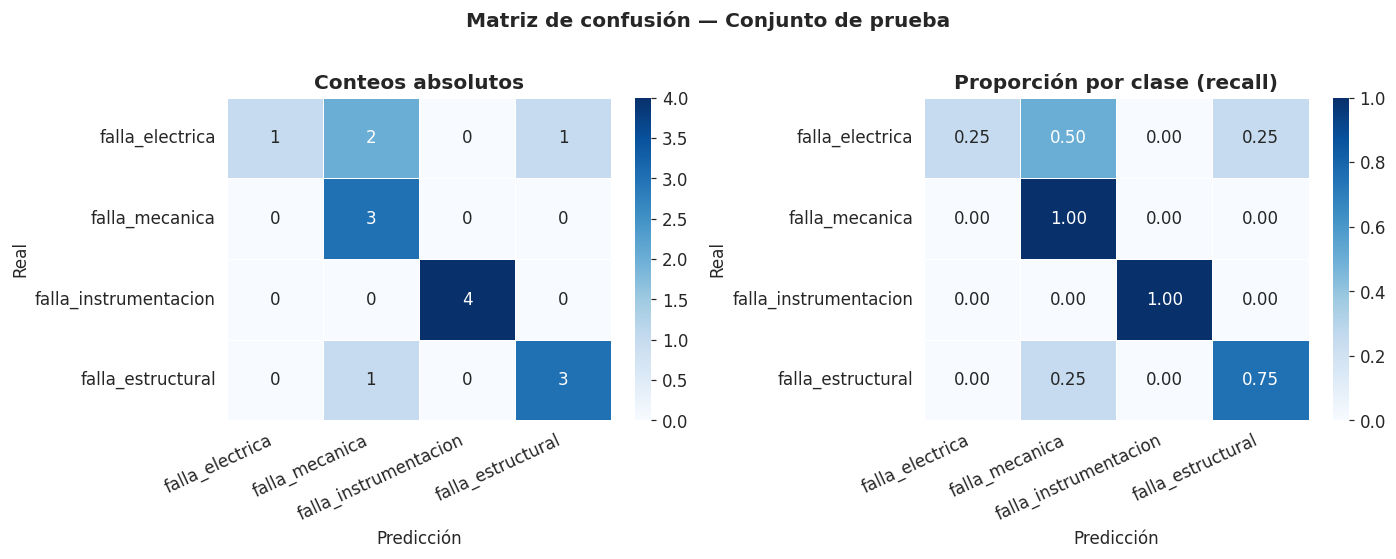

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, titulo in [
    (axes[0], cm,      'd',    'Conteos absolutos'),
    (axes[1], cm_norm, '.2f',  'Proporción por clase (recall)'),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=FAULT_CLASSES, yticklabels=FAULT_CLASSES,
        linewidths=0.5, ax=ax,
    )
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle('Matriz de confusión — Conjunto de prueba', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Mostrar ejemplos clasificados incorrectamente
print('EJEMPLOS MAL CLASIFICADOS')
print('-' * 70)

errores = [
    (X_test[i], y_true[i], y_pred[i])
    for i in range(len(y_true))
    if y_true[i] != y_pred[i]
]

if errores:
    for texto, real, pred in errores:
        print(f'Texto   : "{texto}"')
        print(f'Real    : {FAULT_CLASSES[real]}  (clase {real})')
        print(f'Predicho: {FAULT_CLASSES[pred]}  (clase {pred})')
        print()
else:
    print('¡Sin errores en el conjunto de prueba!')

EJEMPLOS MAL CLASIFICADOS
----------------------------------------------------------------------
Texto   : "el banco de condensadores falló por sobretensión continua"
Real    : falla_electrica  (clase 0)
Predicho: falla_estructural  (clase 3)

Texto   : "el transformador de distribución presentó falla de devanado"
Real    : falla_electrica  (clase 0)
Predicho: falla_mecanica  (clase 1)

Texto   : "la brida presentó una fuga por apriete inadecuado del perno"
Real    : falla_estructural  (clase 3)
Predicho: falla_mecanica  (clase 1)

Texto   : "el cable sufrió un daño por chispa en el tablero eléctrico"
Real    : falla_electrica  (clase 0)
Predicho: falla_mecanica  (clase 1)



---
## § 8 — Inferencia sobre Reportes Nuevos

Probamos el modelo con reportes que **no estaban en el dataset original** para evaluar su capacidad de generalización.

> **Actividad 8.1 —** Agrega al menos 3 reportes propios (inventados o de experiencia real) y analiza si el modelo los clasifica correctamente. Incluye al menos uno ambiguo.

In [ ]:
def predecir(textos: list[str]) -> list[dict]:
    """Clasifica una lista de reportes y retorna clase + probabilidades."""
    model.eval()
    enc = tokenizer(
        textos,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    clases = probs.argmax(axis=1)
    return [
        {
            'texto': t,
            'clase_pred': FAULT_CLASSES[c],
            'confianza': float(probs[i, c]),
            'probabilidades': {FAULT_CLASSES[j]: float(probs[i, j]) for j in range(NUM_CLASSES)},
        }
        for i, (t, c) in enumerate(zip(textos, clases))
    ]


# ── Reportes de prueba (modifica o agrega los tuyos) ─────────────────────────
REPORTES_NUEVOS = [
    "la válvula de alivio no respondió a la señal de control",      # ambiguo: ¿mecánica o instrumentación?
    "el transformador de potencia presentó falla de aislamiento",   # eléctrica
    "la cañería de alta presión sufrió una fisura por fatiga",      # estructural
    "el tacómetro entregó lecturas erráticas durante la operación", # instrumentación
    "el motor eléctrico vibró por desbalance mecánico del rotor",     # mecánica
    "las bombas de agua dejaron de funcionar por falta de energía eléctrica", # eléctrica
    "el sensor de temperatura no detectó el sobrecalentamiento del motor", # instrumentación
]

resultados = predecir(REPORTES_NUEVOS)

for r in resultados:
    print(f'Reporte  : "{r["texto"]}"')
    print(f'Predicción: {r["clase_pred"]}  (confianza: {r["confianza"]:.1%})')
    for cls, p in r['probabilidades'].items():
        barra = '█' * int(p * 30)
        print(f'  {cls: <28} {p:.3f} {barra}')
    print()

Reporte  : "la válvula de alivio no respondió a la señal de control"
Predicción: falla_instrumentacion  (confianza: 31.5%)
  falla_electrica              0.236 ███████
  falla_mecanica               0.221 ██████
  falla_instrumentacion        0.315 █████████
  falla_estructural            0.229 ██████

Reporte  : "el transformador de potencia presentó falla de aislamiento"
Predicción: falla_electrica  (confianza: 28.1%)
  falla_electrica              0.281 ████████
  falla_mecanica               0.248 ███████
  falla_instrumentacion        0.259 ███████
  falla_estructural            0.212 ██████

Reporte  : "la cañería de alta presión sufrió una fisura por fatiga"
Predicción: falla_estructural  (confianza: 28.2%)
  falla_electrica              0.243 ███████
  falla_mecanica               0.275 ████████
  falla_instrumentacion        0.200 ██████
  falla_estructural            0.282 ████████

Reporte  : "el tacómetro entregó lecturas erráticas durante la operación"
Predicción: falla_in

---
## § 9 — Preguntas de Reflexión

Responde de forma breve y razonada en tu reporte de laboratorio:

### 9.1 Selección de modelo
1. ¿Por qué `bert-base-uncased` es una elección sub-óptima para textos técnicos en español? Argumenta usando los datos de tokenización obtenidos en § 3.

Es poco óptimo porque no tiene vocabulario en español, lo que hace que tokenizador fragmente las frases en muchas más subpalabras, lo que crea secuencias más largas.

2. ¿En qué circunstancias estaría justificado usar `bert-base-multilingual-cased` en lugar de BETO?

Está justificado cuando el texto es realmente multilingual, está en más de un idioma o no es solo español.

3. ¿Qué diferencia conceptual hay entre BERT y RoBERTa en cuanto a su estrategia de pre-entrenamiento?

Conceptualmente, BERT usa en pre-entrenamiento la tarea de enmascarar palabras (MLM) y también la tarea de predicción de la siguiente oración (NSP). RoBERTa conserva el MLM pero elimina NSP y ajusta el pre-entrenamiento con enmascarado dinámico y datos más grandes.


### 9.2 Fine-tuning y GPU
4. ¿Qué rol juega el `warmup` en el scheduler de tasa de aprendizaje? ¿Por qué es importante al ajustar modelos grandes?

El warmup hace que la tasa de aprendizaje suba gradualmente desde valores muy bajos a valores más altos. Es importante porque evita oscilaciones, estabiliza el ajuste de pesos y reduce el riesgo de divergencia.

5. Describe cómo `.to(DEVICE)` permite que el mismo código corra en CPU, GPU NVIDIA y Apple Silicon sin modificaciones.

.to(DEVICE) mueve el modelo y los tensores a un backend compatible con el hardware detectado: cpu, cuda o mps. Así, el mismo código funciona en CPU, GPU NVIDIA y Apple Silicon sin cambiar nada, porque el dispositivo escogido se abstrae en DEVICE.

6. ¿Cómo afectaría al entrenamiento duplicar el `batch_size` teniendo suficiente VRAM?

Duplicar el batch_size, si hay VRAM suficiente, suele:

- mejorar el rendimiento por paso al procesar más ejemplos en paralelo,
- reducir el número de pasos por época,
- producir gradientes más suaves,
- pero también puede requerir ajustar la tasa de aprendizaje y, en algunos casos, puede empeorar la generalización si el batch es demasiado grande.

### 9.3 Resultados
7. Analiza los errores encontrados en § 7. ¿Son errores "razonables" (clases parecidas) o aleatorios?

Son razonables cuando las clases son parecidas, donde pueden compartir palabras similares y por ende el modelo tiende a "confundirse".

8. Con solo 60 reportes, ¿qué técnicas aplicarías para mejorar la generalización del modelo?

- validación cruzada para aprovechar mejor los datos,
- regularización y early stopping,
- data augmentation o generación de ejemplos sintéticos,

9. Propón al menos dos formas de aumentar el dataset sin necesidad de etiquetar datos nuevos manualmente.

- generar variantes del texto con sinónimos, paraphraseo o back-translation,
- usar reglas/heurísticas de etiquetado débil sobre textos industriales existentes para crear ejemplos adicionales.

### 9.4 Aplicación industrial
10. ¿Qué riesgos operacionales podría introducir un clasificador con 85% de exactitud en un sistema de mantenimiento predictivo real?

En producción, un 85% de exactitud puede utilizarse como ayuda adicional pero no debe usarse como única fuente de decisión sin validación o controles adicionales, esto porque puede introducir riesgos como:
- decisiones de mantenimiento equivocadas,
- clasificación errónea de la causa de la falla,
- acciones de reparación inadecuadas,
- mayor tiempo de paro y riesgos de seguridad si se confunde una falla crítica con una menos grave.

---
## Desafío Opcional — Comparación Experimental de Modelos

Si terminaste antes de tiempo, implementa el siguiente experimento:

1. Entrena el mismo pipeline con **`bert-base-uncased`** (BERT inglés) sobre el mismo split.
2. Compara las curvas de loss, accuracy final y F1-macro contra tu modelo elegido.
3. Genera un gráfico de barras comparando ambos modelos.
4. Concluye: ¿la diferencia de rendimiento es estadísticamente significativa dado el tamaño del dataset?



Entrenando: bert-base-uncased


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Accuracy: 0.333  |  F1-macro: 0.236

Entrenando: PeterPanecillo/PlanTL-GOB-ES-roberta-base-bne-copy


...

Error during conversion: AttributeError("'str' object has no attribute 'decode'")
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 76, in get_conversion_pr_reference
    raise OSError(
OSError: Could not create safetensors conversion PR. The

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/tulio-chilean-spanish-bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Co

  Accuracy: 0.867  |  F1-macro: 0.854


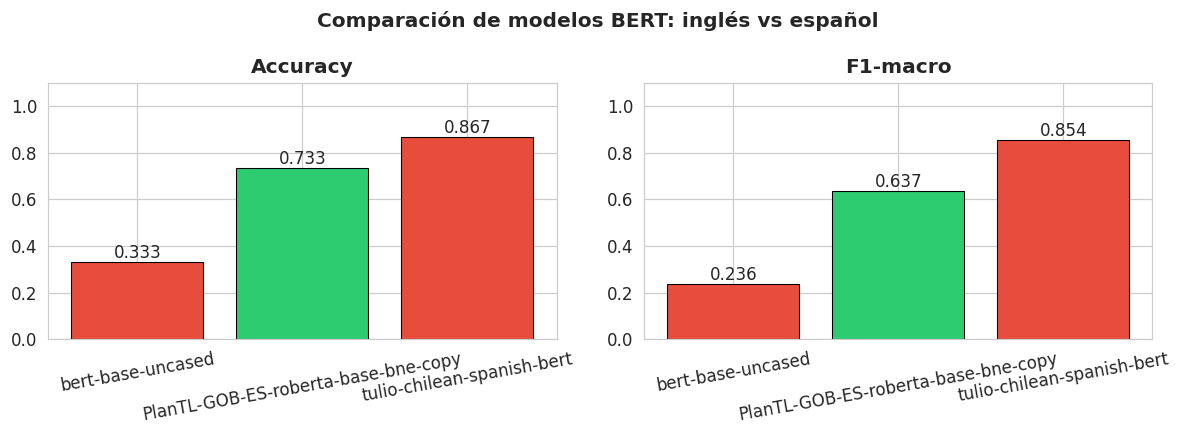

In [ ]:
# ── Completa este código para el desafío opcional ─────────────────────────────
MODELOS_COMPARAR = [
    'bert-base-uncased',
    MODELO_ELEGIDO,
    'dccuchile/tulio-chilean-spanish-bert'
]

resultados_comparacion = {}  # nombre_modelo -> {'acc': ..., 'f1': ...}

for nombre_modelo in MODELOS_COMPARAR:
    print(f'\nEntrenando: {nombre_modelo}')
    tok_cmp  = AutoTokenizer.from_pretrained(nombre_modelo)
    mdl_cmp  = AutoModelForSequenceClassification.from_pretrained(
        nombre_modelo, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
    ).to(DEVICE)

    ds_tr = ReportesDataset(X_train, y_train, tok_cmp, MAX_LEN)
    ds_te = ReportesDataset(X_test,  y_test,  tok_cmp, MAX_LEN)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
    dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE)

    opt_cmp = torch.optim.AdamW(mdl_cmp.parameters(), lr=2e-5, weight_decay=0.01)
    sch_cmp = get_linear_schedule_with_warmup(
        opt_cmp,
        num_warmup_steps=int(len(dl_tr) * NUM_EPOCHS * 0.1),
        num_training_steps=len(dl_tr) * NUM_EPOCHS,
    )

    for ep in range(NUM_EPOCHS):
        mdl_cmp.train()
        for batch in dl_tr:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            opt_cmp.zero_grad()
            loss = mdl_cmp(**batch).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl_cmp.parameters(), 1.0)
            opt_cmp.step()
            sch_cmp.step()

    mdl_cmp.eval()
    preds_cmp, labels_cmp = [], []
    with torch.no_grad():
        for batch in dl_te:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            preds_cmp.extend(mdl_cmp(**batch).logits.argmax(1).cpu().tolist())
            labels_cmp.extend(batch['labels'].cpu().tolist())

    resultados_comparacion[nombre_modelo] = {
        'acc': accuracy_score(labels_cmp, preds_cmp),
        'f1' : f1_score(labels_cmp, preds_cmp, average='macro'),
    }
    print(f'  Accuracy: {resultados_comparacion[nombre_modelo]["acc"]:.3f}  |  F1-macro: {resultados_comparacion[nombre_modelo]["f1"]:.3f}')

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
nombres_cortos_cmp = [m.split('/')[-1] for m in MODELOS_COMPARAR]

for ax, metrica, titulo in [
    (axes[0], 'acc', 'Accuracy'),
    (axes[1], 'f1',  'F1-macro'),
]:
    vals = [resultados_comparacion[m][metrica] for m in MODELOS_COMPARAR]
    bars = ax.bar(nombres_cortos_cmp, vals, color=['#E74C3C', '#2ECC71'],
                  edgecolor='black', linewidth=0.7)
    ax.bar_label(bars, fmt='%.3f', fontsize=11)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(nombres_cortos_cmp, rotation=10)

plt.suptitle('Comparación de modelos BERT: inglés vs español', fontweight='bold')
plt.tight_layout()
plt.show()